In [1]:
### Notebook here takes d.paint c-mods that only modulate a single condensate, clusters them by structure, and looks for enrichment, including:
### > Running filtering of c-mods
### > Clustering c-mods by their structure, and calculating enrichment of structure clusters with c-mods targeting specific condensates (Fig 5b, 5c)

In [2]:
import ast
import math
import pandas as pd
import numpy as np
import re
from rdkit import Chem, rdBase
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys
from rdkit.Chem import FilterCatalog
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde
from scipy.stats import fisher_exact

In [3]:
rdBase.DisableLog("rdApp.*")

In [4]:
sns.set_style("whitegrid")

In [5]:
#Load dataset of c-mods from d.paint 20 screen
cmods_df = pd.read_csv("./data/dpaint20_cmods.csv")
cmods_df["chemformer"] = cmods_df["chemformer"].apply(ast.literal_eval)
cmods_df["Set"] = "C-mod"

In [6]:
#Load dataset of c-mods with only 1 condensate perturbed
cmods_df_marker_perturbed = pd.read_excel(
    "./data/dpaint20_cmpds_and_cmods.xlsx",
    sheet_name="Top_5_1only_plus_condensate",
)

In [7]:
#Join together
cmods_df = cmods_df.merge(
    cmods_df_marker_perturbed[["compound_id", "Marker"]],
    on="compound_id",
    how="inner",
)

In [8]:
#Check whether any c-mods have <1 condensate perturbed
n_null = cmods_df["Marker"].isna().sum()
print(f"Number of cmods with no marker annotation in cmods_df: {n_null}")

Number of cmods with no marker annotation in cmods_df: 0


In [9]:
#Function to calculate chemical descriptors

def calc_mol_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    def safe_div(num, denom):
        return float(num) / float(denom) if denom else 0.0
    
    num_heavy_atoms = Descriptors.HeavyAtomCount(mol)
    num_aromatic_atoms = sum(atom.GetIsAromatic() for atom in mol.GetAtoms())
    num_ring_atoms = sum(atom.IsInRing() for atom in mol.GetAtoms())
    valence_e = Descriptors.NumValenceElectrons(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    num_rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    
    return {
        "QED": Descriptors.qed(mol),
        "LogP": Descriptors.MolLogP(mol),
        "MW": Descriptors.ExactMolWt(mol),
        "# of valence electrons": Descriptors.NumValenceElectrons(mol),
        "# of rings": Descriptors.RingCount(mol),
#        "# of heavy atoms": Descriptors.HeavyAtomCount(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "# of rotatable bonds": num_rotatable_bonds,
        "TPSA": Descriptors.TPSA(mol),
        "# of aromatic rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "ratio rotatable bonds to atoms": safe_div(num_rotatable_bonds,num_heavy_atoms),
        "fraction atoms in aromatic rings": safe_div(num_aromatic_atoms,num_heavy_atoms), 
        "fraction atoms in rings": safe_div(num_ring_atoms,num_heavy_atoms),
        "ratio valence electrons to atoms": safe_div(valence_e,num_heavy_atoms),
        "fraction HBD": safe_div(hbd,num_heavy_atoms),
        "fraction HBA": safe_div(hba,num_heavy_atoms),
    }

In [10]:
#Calculate chemical descriptors for c-mods
mol_desc = cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
desc_cols = mol_desc.columns
cmods_df = cmods_df.join(mol_desc)

In [11]:
#Function to build PAINS catalog for filtering
def build_pains_catalog():
    pains_params = FilterCatalog.FilterCatalogParams()
    pains_sets = [
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A,
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B,
#        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C, << Only use High (A) and Medium (B) filters for now
    ]
    for p in pains_sets:
        pains_params.AddCatalog(p)
    return FilterCatalog.FilterCatalog(pains_params)

pains_catalog = build_pains_catalog()

In [12]:
#Function to remove any null smiles
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(smiles)

In [13]:
#Function to run PAINS filtering using catalog generated
def is_pains(mol):
    return pains_catalog.HasMatch(mol)

In [14]:
#Apply to c-mods
cmods_df["rdkit_mol"] = cmods_df["SMILES"].apply(smiles_to_mol)

cmods_df["is_pains"] = cmods_df["rdkit_mol"].apply(is_pains)

cmods_filtered_df = cmods_df[~cmods_df["is_pains"]].copy()

In [15]:
#Remove any c-mods >1000Da
cmods_filtered_df = cmods_filtered_df[cmods_filtered_df["MW"] < 1000]

In [16]:
#Check number of compounds in each set, before and after filtering

pd.DataFrame(
    {
        "C-mod": [len(cmods_df)],
        "Filtered c-mod": [len(cmods_filtered_df)],
    },
    index=["Number of compounds"],
).style.set_table_styles(
    [
        {"selector": "td", "props": [("border", "1px solid black")]},
        {"selector": "th", "props": [("border", "1px solid black")]},
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
        {"selector": "caption", "props": [("font-weight", "bold")]},
    ],
).format(
    "{:,}"
)

,C-mod,Filtered c-mod
Number of compounds,271,238


/home/ubuntu/.anaconda3/envs/cmods/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


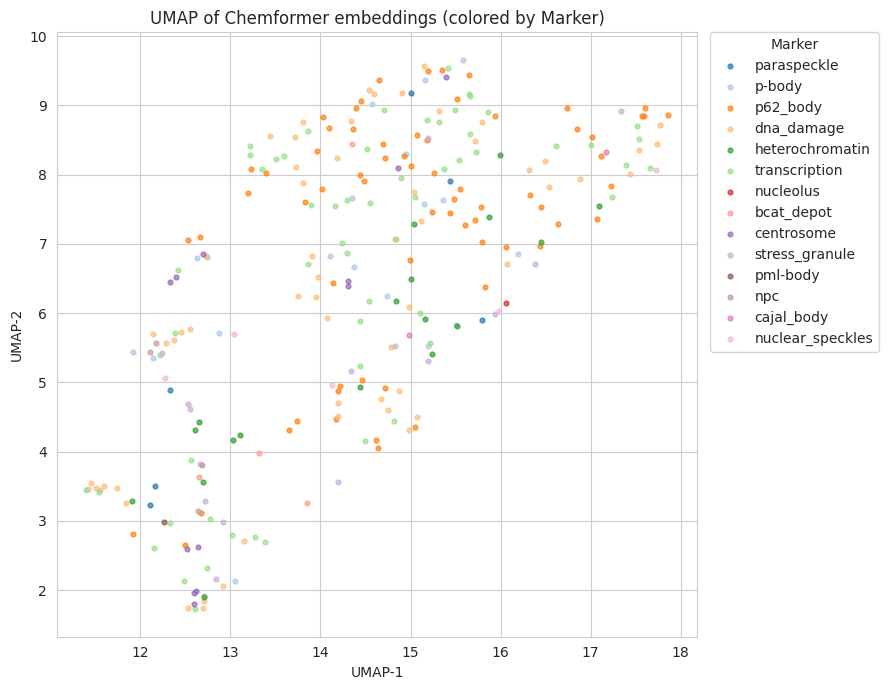

In [17]:
# Plot UMAP of c-mods by their Chemformer embeddings
df = cmods_df.dropna(subset=["chemformer", "Marker"]).copy()

# Stack embeddings into (n_samples, n_features)
X = np.vstack(df["chemformer"].values)
markers = df["Marker"].astype(str).values
unique_markers = pd.unique(markers)

# --- run UMAP ---
umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
Z = umap.fit_transform(X)

#plot, colored by condensate
fig, ax = plt.subplots(figsize=(9, 7))

cmap = plt.get_cmap("tab20")
for i, m in enumerate(unique_markers):
    mask = (markers == m)
    ax.scatter(
        Z[mask, 0], Z[mask, 1],
        s=12, alpha=0.7,
        label=m,
        color=cmap(i % cmap.N),
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP of Chemformer embeddings (colored by Marker)")
ax.legend(title="Marker", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
plt.show()

/home/ubuntu/.anaconda3/envs/cmods/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


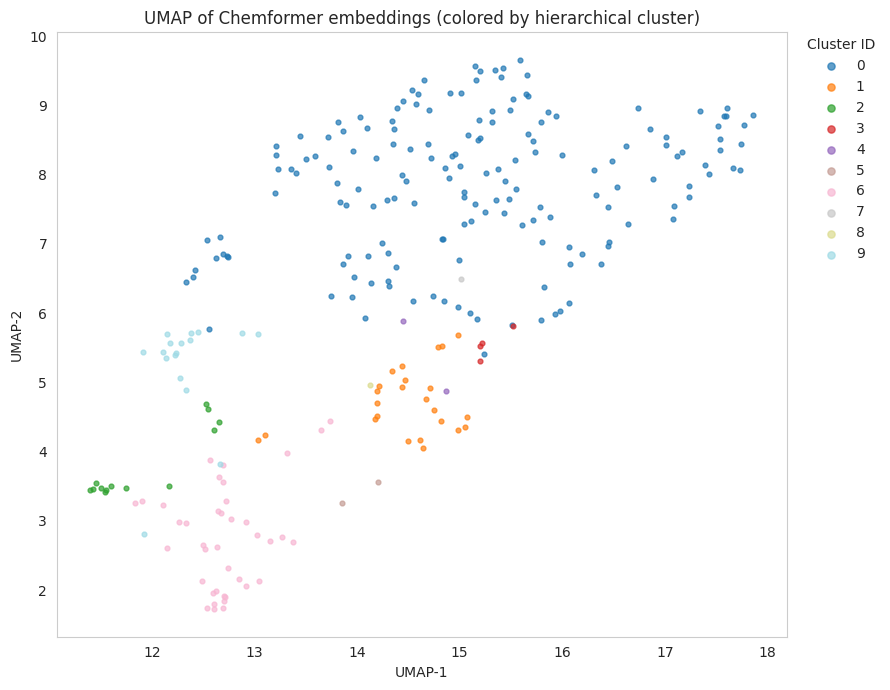

In [25]:
#Run hierarchical clustering and calculate significance

N_CLUSTERS = 10

df = cmods_df.dropna(subset=["chemformer", "Marker"]).copy()
X = np.vstack(df["chemformer"].values).astype(np.float32)
markers = df["Marker"].astype(str)

# Hierarchical clustering

try:
    clusterer = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        linkage="average",
        metric="cosine",
    )
except TypeError:
    clusterer = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        linkage="average",
        affinity="cosine",
    )

df["cluster"] = clusterer.fit_predict(X)


# Benjamini–Hochberg helper

def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan)

    valid = np.isfinite(pvals)
    pv = pvals[valid]
    if pv.size == 0:
        return qvals

    order = np.argsort(pv)
    pv_sorted = pv[order]
    m = pv_sorted.size

    q_sorted = pv_sorted * m / (np.arange(1, m + 1))
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q_unsorted = np.empty_like(q_sorted)
    q_unsorted[order] = q_sorted
    qvals[valid] = q_unsorted
    return qvals


# Enrichment + Fisher tests

N = len(df)
cluster_sizes = df["cluster"].value_counts().sort_index()
marker_totals = markers.value_counts()

rows = []
for clust, n_in_cluster in cluster_sizes.items():
    in_cluster = (df["cluster"] == clust)

    for m, K_total_marker in marker_totals.items():
        is_marker = (markers == m)

        k = int((in_cluster & is_marker).sum())  # observed in cluster
        expected = n_in_cluster * (K_total_marker / N)

        enrichment_rate = (k / expected) if expected > 0 else np.nan

        a = k
        b = int(n_in_cluster - k)
        c = int(K_total_marker - k)
        d = int((N - n_in_cluster) - c)

        if min(a, b, c, d) < 0:
            pval = np.nan
        else:
            _, pval = fisher_exact([[a, b], [c, d]], alternative="greater")

        rows.append({
            "cluster": int(clust),
            "marker": m,
            "n_in_cluster": int(n_in_cluster),
            "marker_total": int(K_total_marker),
            "observed_in_cluster": int(k),
            "expected_in_cluster": float(expected),
            "enrichment_rate": float(enrichment_rate),
            "p_value": float(pval) if np.isfinite(pval) else np.nan,
        })

full_table = pd.DataFrame(rows)
full_table["q_value"] = benjamini_hochberg(full_table["p_value"].values)

full_table = full_table.sort_values(
    ["q_value", "cluster", "marker"],
    ascending=[True, True, True]
).reset_index(drop=True)

sig_table = full_table.loc[full_table["q_value"] < 0.1].copy()


# UMAP plot colored by cluster

umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
Z = umap.fit_transform(X)

clusters = df["cluster"].astype(int).to_numpy()
unique_clusters = np.sort(np.unique(clusters))

fig, ax = plt.subplots(figsize=(9, 7))

# discrete colormap with enough distinct colors
cmap = plt.get_cmap("tab20", len(unique_clusters))

for i, cl in enumerate(unique_clusters):
    mask = clusters == cl
    ax.scatter(
        Z[mask, 0], Z[mask, 1],
        s=12, alpha=0.7,
        color=cmap(i),
        label=f"{cl}",
    )

ax.set_title("UMAP of Chemformer embeddings (colored by hierarchical cluster)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.grid(False)

# legend with colored markers per cluster
ncol = 2 if len(unique_clusters) > 10 else 1
ax.legend(
    title="Cluster ID",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    ncol=ncol,
    markerscale=1.5,
)

fig.tight_layout()
#plt.savefig("cluster_id_umap_transparent.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


In [26]:
sig_table

,cluster,marker,n_in_cluster,marker_total,observed_in_cluster,expected_in_cluster,enrichment_rate,p_value,q_value
0,0,p62_body,168,67,54,41.535055,1.300107,0.000172,0.024119


In [27]:
full_table.sort_values("q_value", ascending=True).head(10)

,cluster,marker,n_in_cluster,marker_total,observed_in_cluster,expected_in_cluster,enrichment_rate,p_value,q_value
0,0,p62_body,168,67,54,41.535055,1.300107,0.000172,0.024119
1,6,centrosome,39,12,5,1.726937,2.895299,0.017681,0.723744
2,8,nuclear_speckles,1,5,1,0.018450,54.200000,0.018450,0.723744
3,9,npc,17,4,2,0.250923,7.970588,0.020678,0.723744
4,2,dna_damage,13,58,6,2.782288,2.156499,0.036994,0.739882
5,5,bcat_depot,2,4,1,0.029520,33.875000,0.029356,0.739882
6,9,nuclear_speckles,17,5,2,0.313653,6.376471,0.033188,0.739882
92,6,npc,39,4,2,0.575646,3.474359,0.100361,1.000000
93,6,nuclear_speckles,39,5,0,0.719557,0.000000,1.000000,1.000000
94,6,nucleolus,39,1,0,0.143911,0.000000,1.000000,1.000000


In [46]:
# Save the two tables to CSV (no index)
#full_table.to_csv("cluster_marker_enrichment_all.csv", index=False)
#sig_table.to_csv("cluster_marker_enrichment_significant.csv", index=False)

In [21]:
#Report the number of c-mods in groups of interest
cluster_of_interest = 0
marker_of_interest = "p62_body"

tmp = df.copy()

tmp["P62_flag"] = tmp["Marker"].astype(str).eq(marker_of_interest).map({True: "P62", False: "Not P62"})
tmp["Cluster_flag"] = tmp["cluster"].astype(int).eq(cluster_of_interest).map(
    {True: f"cluster {cluster_of_interest}", False: f"not cluster {cluster_of_interest}"}
)

tmp["Group4"] = tmp["P62_flag"].astype(str).str.cat(tmp["Cluster_flag"].astype(str), sep=" & ")

group_counts = (
    tmp["Group4"]
    .value_counts()
    .reindex([
        f"P62 & cluster {cluster_of_interest}",
        f"Not P62 & cluster {cluster_of_interest}",
        f"P62 & not cluster {cluster_of_interest}",
        f"Not P62 & not cluster {cluster_of_interest}",
    ], fill_value=0)
    .rename_axis("Group")
    .reset_index(name="Count")
)

group_counts


,Group,Count
0,P62 & cluster 0,54
1,Not P62 & cluster 0,114
2,P62 & not cluster 0,13
3,Not P62 & not cluster 0,90


/home/ubuntu/.anaconda3/envs/cmods/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


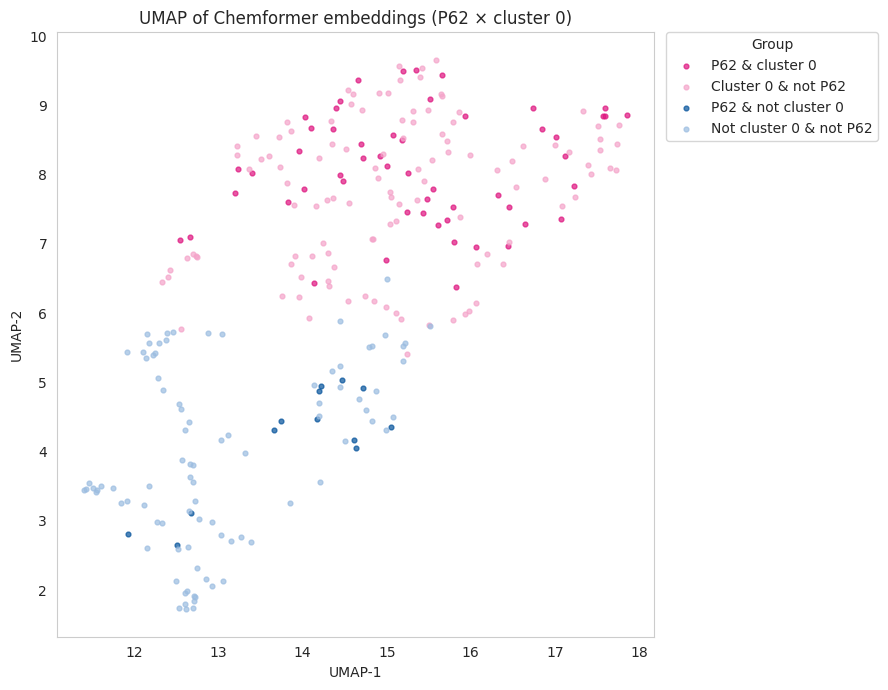

In [22]:
# Produce UMAP plot colored just for groups of interest

cluster_of_interest = 0
marker_of_interest = "p62_body"

# 4-category label: (P62 vs not) x (cluster0 vs not)
is_p62 = df["Marker"].astype(str).eq(marker_of_interest)
is_c0  = df["cluster"].astype(int).eq(cluster_of_interest)

df["Set4"] = "unassigned"
df.loc[is_p62 & is_c0,  "Set4"] = "P62 & cluster 0"
df.loc[~is_p62 & is_c0, "Set4"] = "Cluster 0 & not P62"
df.loc[is_p62 & ~is_c0, "Set4"] = "P62 & not cluster 0"
df.loc[~is_p62 & ~is_c0,"Set4"] = "Not cluster 0 & not P62"

order4 = ["P62 & cluster 0", "Cluster 0 & not P62", "P62 & not cluster 0", "Not cluster 0 & not P62"]
df["Set4"] = pd.Categorical(df["Set4"], categories=order4, ordered=True)

# Stack embeddings into (n_samples, n_features)
X = np.vstack(df["chemformer"].values).astype(np.float32)
labels = df["Set4"].astype(str).values

#run UMAP
umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
Z = umap.fit_transform(X)

# --- plot ---
plot_palette4 = {
    "P62 & cluster 0": "#DE137E",
    "Cluster 0 & not P62": "#F4A3C9",
    "P62 & not cluster 0": "#03529B",
    "Not cluster 0 & not P62": "#9BBCE0",
}

fig, ax = plt.subplots(figsize=(9, 7))
for key in order4:
    mask = labels == key
    ax.scatter(
        Z[mask, 0], Z[mask, 1],
        s=12, alpha=0.7,
        label=key,
        color=plot_palette4[key],
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP of Chemformer embeddings (P62 × cluster 0)")
ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(False)
fig.tight_layout()
#plt.savefig("cluster_umap_transparent.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()
